# Partie 1  - Dynamique de populations 

### ATTENTION: 
> ###  Les questions théoriques sont à faire sur copies d'examen. Elles sont rappelées dans l'énoncé.

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np 
import matplotlib.pyplot as plt

## Exercice 1 : Le modèle de Verhulst 
Le modèle de Verhulst peut être considéré sous une forme discrète en temps. L'effectif de la population est alors modélisé par la suite logistique :
$$ 
N_{n+1} \ = \ N_n  + r \, N_n \Bigl(1- \frac{N_n}{K} \Bigr) \ ,$$
pour $N_0\ge0$ donné,
où $K$ est la capacité biotique et $r$ le taux de croissance de la population. 

Dans son étude le modèle est  simplifié en posant $\mu=r+1$ et $u_{n}=\frac{r}{\mu K} \ N_{n}$.  
On se ramène à la suite récurrente 
$$
u_{n+1}=f_{\mu}(u_{n}),
$$ 
où
$$
f_{\mu}(x) \ = \ \mu \, x \, (1-x) \ .
$$
Il ne reste plus qu'à étudier le comportement de la uite $(u_{n})$ pour $\mu \in \, ]1,4]$.


### Question 1-1 : (A fournir sur ce notebook)
On souhaite observer le comportement  de la **limite** de cette suite pour différentes valeurs de $\mu\in [1,4[ $.

#### Question 1-1-1: Construction des termes de la suite
>> Fournir une finction `termesSuites(u0, mu, M)` qui prend en argument la valeur initiale `u0`, le tau de croissance `mu` et un entier `M` et qui retourne un **numpy array** contenant les `M` premiers termes de la suite.  

In [2]:

def f(x,mu):
    return mu * x * (1 - x)


def termesSuites(u0, mu, M):
    u =[u0]
    for i in range(M):
        u.append( f(u[-1], mu) )
    return np.array(u) 



#### Question 1-1-2: Représentation de la suite ( diagramme de Feigenbaum )

On va représenter l'évolution des limites de la population en fonction des valeurs de $\mu \in ]1,4[$.

Pour cela dans une figure

> - générer $1000$ valeurs de $\mu [1,4]$ à l'aide de de la fonction `linspace` du module `numpy`
> - et pour chaque valeur de `mu`, caluler les $200$ permiers termes de la suite avec une donnée initiale 
`u0=0.1` ou générée aléatoire et représenter les $100$ derniers sur un même graphique en plaçant un point (`.`) 
à la coordonnée $(\mu, u_m), m=100, .., 200$. <br>
(*on pourra utiliser une commande du type `plt.plot(0 * u[100:] + mu, u[100:], 'k.', markersize=1)` où `u` est  le vecteur des $200$ termes de la suite obtenus par votre fonction `termesSuites(...)` ci-dessus*)

Dans un autre graphique (qu'on peut mettre à coté du précédent), reprendre le même graphique,
en ajoutant cette fois :
> - pour chaque valeur $\mu$ le point de coordoonnée $(\mu, l_\mu)$, où $l_\mu$ est le point fixe de $f_\mu$.<br>
 (*On mettra ce point en couleur rouge*).
> - les droites verticales $\mu = 3, \mu = 3.449, \mu = 3.57$ (*On mettra une legende pour identifier ces droites*).

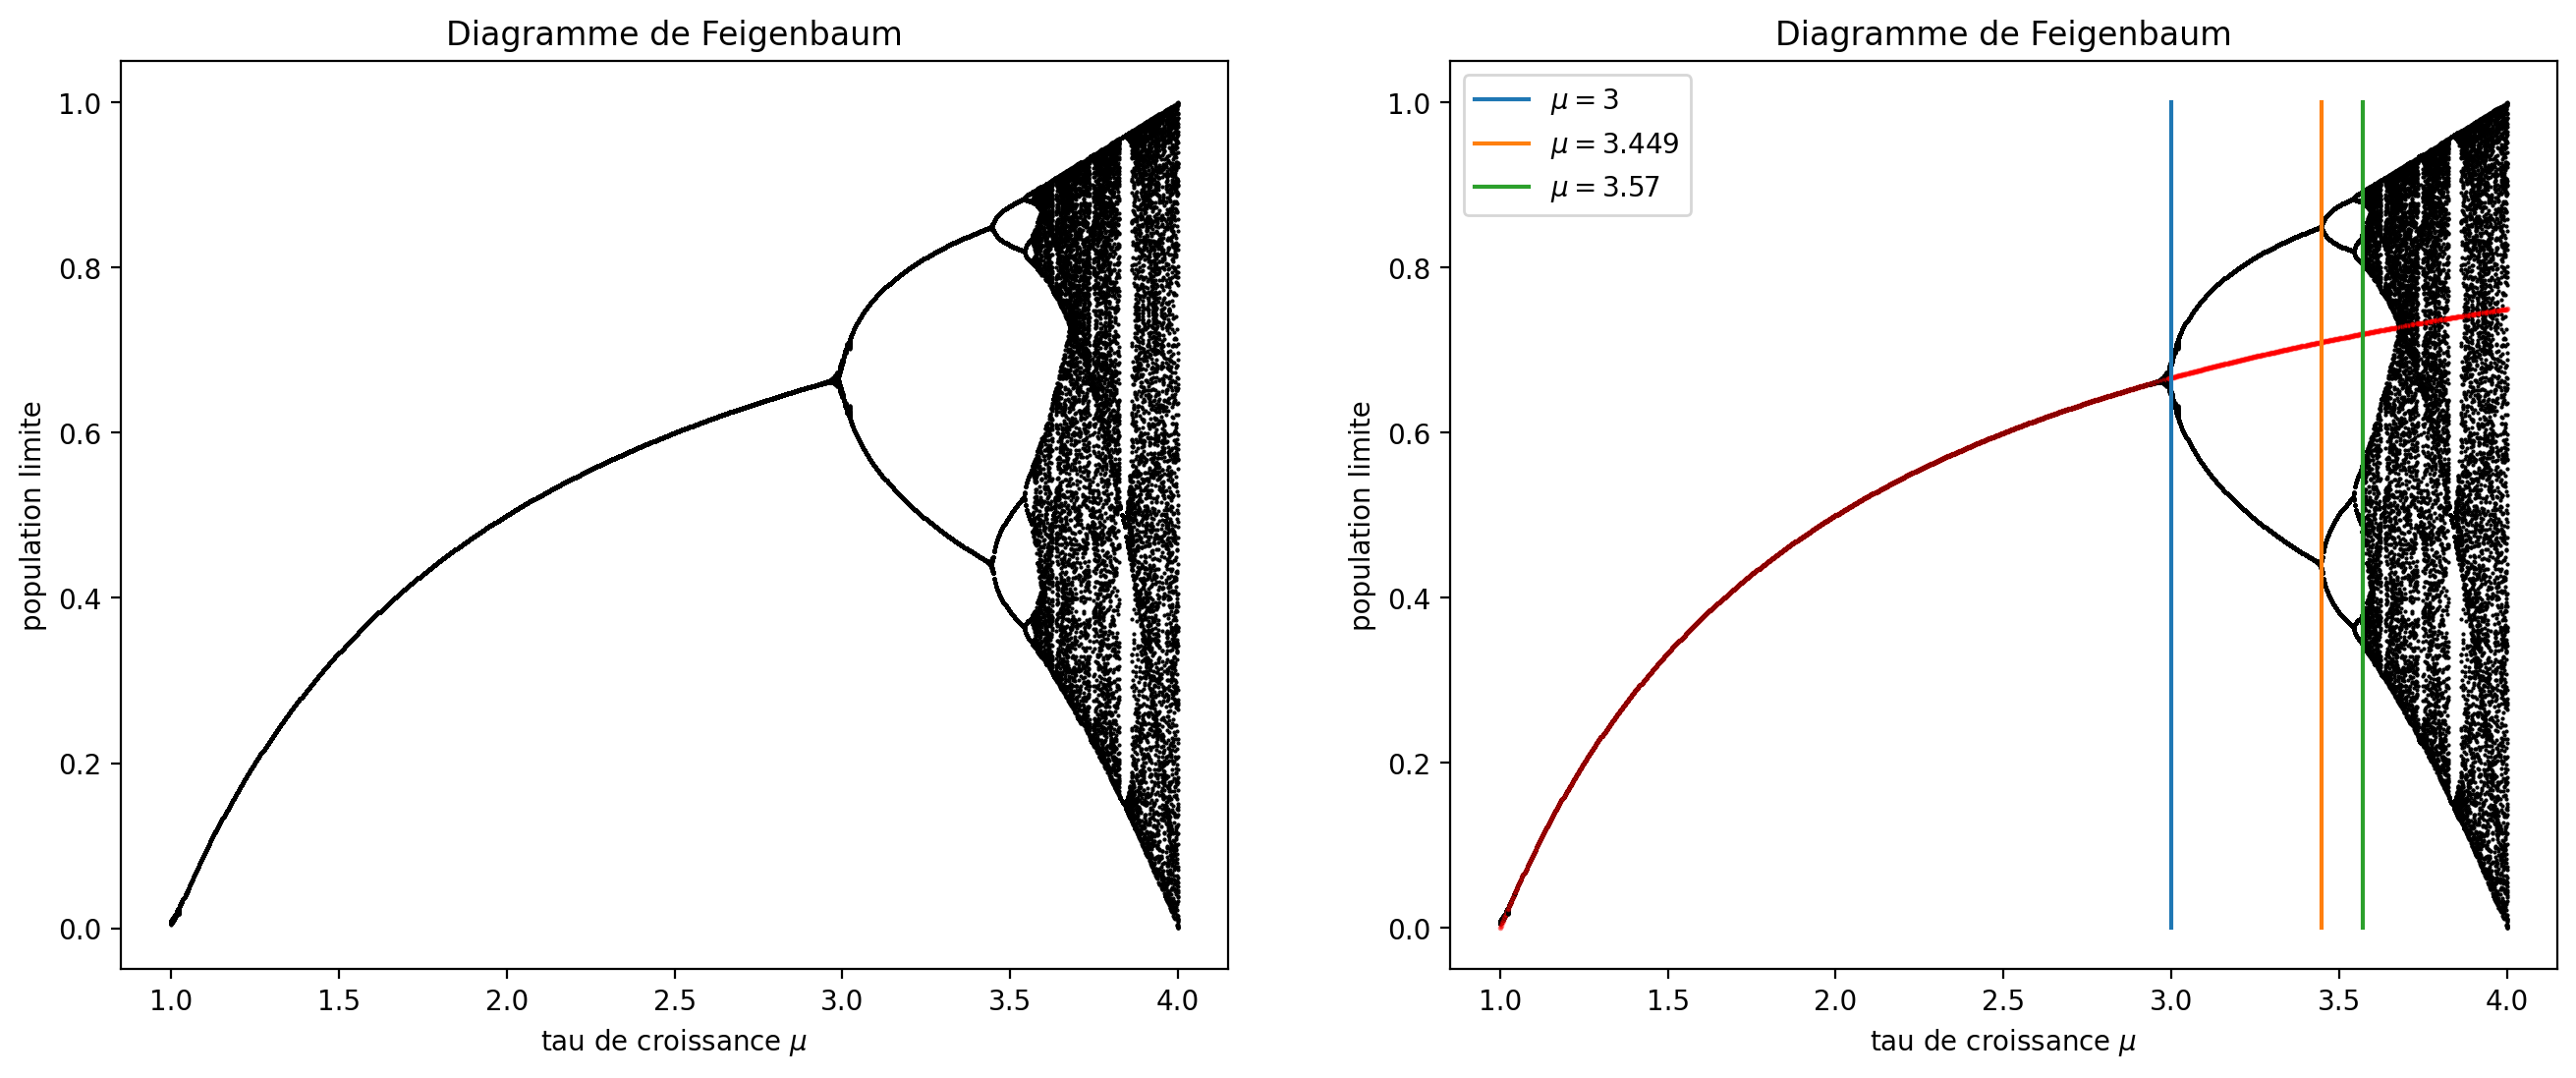

In [42]:
fig, ax = plt.subplots(1,2, figsize=(16,6))
muList = np.linspace(1., 4., 1000)
for mu in muList:
    u0 = np.random.rand()
    u = termesSuites(u0, mu, 200)
    ax[0].plot(0. * u[100:] + mu, u[100:], 'k.', markersize=1)
    ax[1].plot(0. * u[100:] + mu, u[100:], 'k.', markersize=1)
    ax[1].plot(mu, (mu -1)/mu, 'r.', markersize=2, alpha=0.5)
ax[1].plot([3,3],[0,1], label = "$\mu = 3$")
ax[1].plot([3.449,3.449],[0,1], label = "$\mu = 3.449$")
ax[1].plot([3.57,3.57],[0,1],label = "$\mu = 3.57$")
ax[1].legend()

for i in range(2):
    ax[i].set_title("Diagramme de Feigenbaum")
    ax[i].set_xlabel("tau de croissance $\mu$")
    ax[i].set_ylabel("population limite")

### Question 1-2 : (A Fournir sur ce notebook)  
> Quelles observations faites-vous sur la convergence de la suite logistique ?

elle diverge


## Exercice 2 : Système proie-prédateur (modèle simplifié de Lotka-Volterra)

Le modèle de prédateur-proie de la dynamique de populations (*adimensionné* ou *mis à l'échelle*) peut se mettre sous la forme : 

\begin{equation*}
     \begin{cases}
       x'(t) =  x(t)\, (y(t)-1), \quad t \in ]0,T[ \\
       y'(t) =  y(t)\, (1-x(t)).
     \end{cases}
\end{equation*}
On suppopose les populations connues à l'instant initiale $t=0$: 
\begin{equation*}
     \begin{cases}
    x(0) = x_0, \\
    y(0) = y_0,
     \end{cases}
\end{equation*}
où $x_0\ge 0$ et $y_0\ge 0$ sont donnés.



### Question 2-1 :  (Question de cours) 

> Précisez laquelle de $x(t)$, $y(t)$ représente la population des prédateurs à l'instant $t$,
et laquelle représente celle des proies. <br>
> (**Réponse et justification à fournir sur la copie d'examen**) 


y proie, x predateur.

### Question 1-2 : Champs de vecteurs et solution numérique par odeint
> 1. Représentez dans l'espace des phases $(x,y)$ le champ de vecteurs associé à ce système d'équations.
<br> *(On pourra prendre une grille de $[\frac{1}{10}, 3] \times [\frac{1}{10},3]$ formée de `25` points en abscisses et en ordonnées)*

> 2. En utilisant la fonction `odeint` du module `scipy.integrate`, construisez la solution approchée de ce 
système.<br> (*Pour les applications numériques, on prendra $T = 100$, $N = 1000$, $x(0) = 1$, $y(0) = 0.5$*). 
<br> Puis tracer dans la même figure ci-dessus le portrait de phase (i.e l'évolution de $y$ en fonction de $x$). <br> Rendez visible le point de départ et le point d'équilibre du système. 


Les indications ci-dessous sont identiques à celles données en TDM.

> (**Indication:** Pour les chanps de vecteurs,  on pourra 
commencer par poser $X=(x,y)$, puis réécrire le système sous la forme  $X^{′} = F(X)$  où  $F = (F_1, F_2)$  avec  $F_1, F_2$  deux fonctions définies sur  $\mathbb{R}^2$  à valeurs dans  $\mathbb{R}$.
)

> (**Indication:** Pour utiliser `odeint`, on pourra commencer par définir la fonction second membre (attention à l'ordre des arguments) : $ F(X, t) = (F_1(X), F_2(X))^t,$ où $X=(x,y) \in R^2$. Puis Construire le vecteur $t = (t^0,\ldots,t^N)$ des temps discrets où la solution approchée sera calculée).

In [49]:
# VOUS POUVEZ POUR CELA COMMENCER PAR COMPLETER CETTE CELLULE

def F1(x, y):
    """fonction second membre pour x'"""  
    return x * (y-1)

def F2(x, y):
    """fonction second membre pour y'"""   
    return y * (1-x)

def F(X, t):
    """fonction second membre pour le système nécessaire pour odeint """
    x,y = X
    return np.array([F1(x,y), F2(x,y)])
    

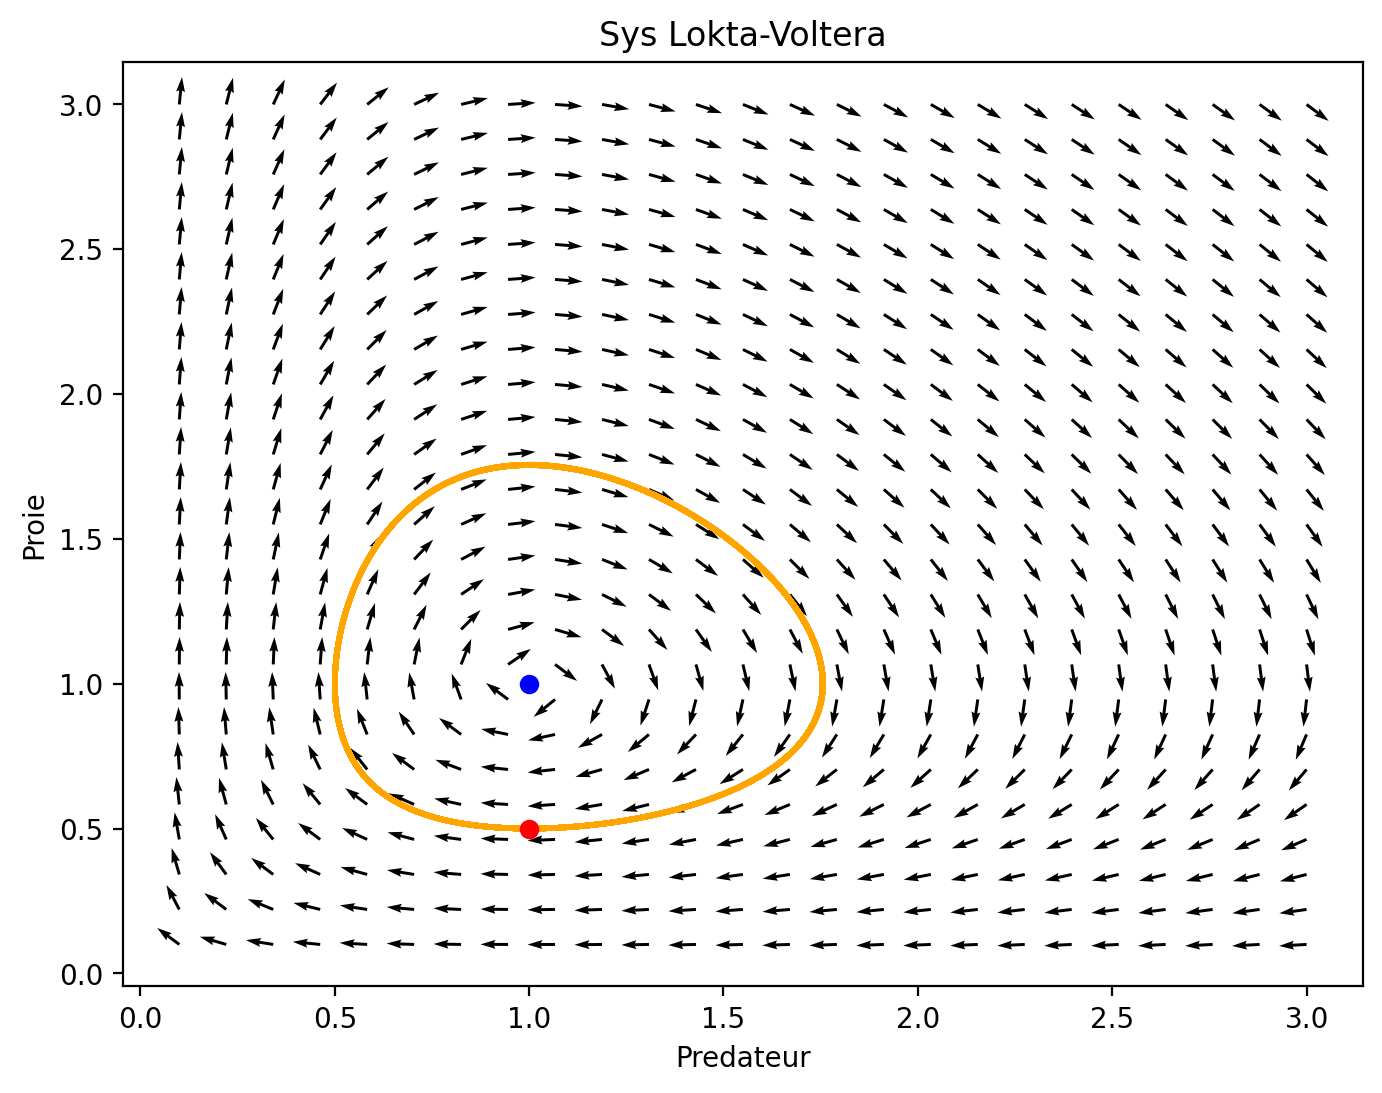

In [81]:
# METTRE VOTRE REPONSE ICI

# VOUS POUVEZ A VOTR GUISE COMPLETER CETTE CELLULE OU REDEFINIR UNE AUTRE 

from scipy.integrate import odeint


# POINT D'EQUILIBRE
xe = 1
ye = 1

# CALCUL DU CHAMP DE VECTEURS
l1 = np.linspace(0.1, 3, 25)
x, y = np.meshgrid( l1, l1)

f1 = F1(x,y)
f2 = F2(x,y)
norme = np.sqrt(f1**2 + f2**2)
f1 = f1/norme
f2 = f2/norme

# CALCUL DE SOLUTION APPROCHEE AVEC odeint

T, N = 100, 1000
x0, y0 = 1, 0.5
t = np.linspace(0,T,N+1)
solApprochee = odeint(F, np.array([x0,y0]),t)

# GRAPHIQUE

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)

# dessin chanp de vecteurs

ax.quiver(x, y, f1, f2, angles='xy')
#dessin solution

xa = solApprochee[:,0]
ya = solApprochee[:,1]

ax.plot(xa, ya, linewidth=2, color='orange')


#dessin point de depart xo,y0

ax.plot(x0, y0, 'ro')

#dessin point d'équilibre xe, ye

ax.plot(1, 1, 'bo')

# titre et autres
ax.set_title("Sys Lokta-Voltera")
ax.set_xlabel("Predateur")
ax.set_ylabel("Proie")
plt.show()

### Question 2-2 : Période et son comportement

On va à présent non seulement déterminer la période de la solution, mais aussi déterminer le comportement de 
cette période lorsque $y_0$ tend vers $0$, où la donnée initiale est $(x_e, y_0)$ avec $ y_0 \in]0,y_e[$ et  $(x_e, y_e)$ est le point d'équilibre. 

Pour cela, on fournit la cellule suivante qui est comparable à celle vue en TDM. 

In [88]:
# VOUS ETES LIBRES D4EXPLOITER CETTE LE CONTENU DE CETTE CELLULE
# ELLE EST IDENTIQUE A UNE CELLULE RENCONTREE EN TP

def IndicesPourPeriode(t, x, y, xe, ye):
    n = len(t)
    Id = []
    for i in range(n-1):
        if( x[i] >= xe and x[i+1] < xe and y[i] < ye):  
            Id.append(i)
    return Id

Id = IndicesPourPeriode(t, xa, ya, xe, ye)
if( len(Id) > 1 ) :
    print (" La solution est périodique !!!!!!!!")
    texte = "\n La periode observée pour la donnée initiale (x0, y0) = ({:.0f},{:.0f}) est: T = {:5.2f}"
    print(texte.format(x0,y0,t[Id[1]] - t[Id[0]]))

 La solution est périodique !!!!!!!!

 La periode observée pour la donnée initiale (x0, y0) = (1,0) est: T =  6.40


> #### Question 2-2-1:
>> Fournir une fonction `periodeAssociee(y0, xe, ye)`  qui prend en argument `y0, xe, ye` et qui résoud par 
`oedint` le système prédateur-proie avec comme donnée initiale `(xe, y0)` sur un intervalle `[0,200]` avec `1000` points  et qui retourne la période associée. 

In [96]:
# UTILISEZ CETT CELLULE POUR LA REPONSE

def periodeAssociee(y0, xe, ye):
    T, N = 200, 1000
    t = np.linspace(0,T,N+1)
    sol = odeint(F,np.array([xe,y0]),t)
    x = sol[:,0]
    y = sol[:,1]
    Id = IndicesPourPeriode(t, x, y, xe, ye)
    return  t[Id[1]] - t[Id[0]]


> #### Question 2-2-2:
>> A l'aide de la question précédente, montrer que lorsque $y_0$ tend vers $0$ , la période tend vers l'infini.
Mais que cette convergence vers l'infini est logarithmique. 
(**On pourra représenter la courbe qui à $y_0$ associe la période pour 500 valeurs de $y_0 \in ]10^{-6}, \frac{1}{2}[$**)


In [97]:
y0 , xe, ye = 0.5, 1., 1.
print(f" Pour y0 = {y0:3.2f} la période est  {periodeAssociee(y0, xe, ye):3.2f}")


 Pour y0 = 0.50 la période est  6.40


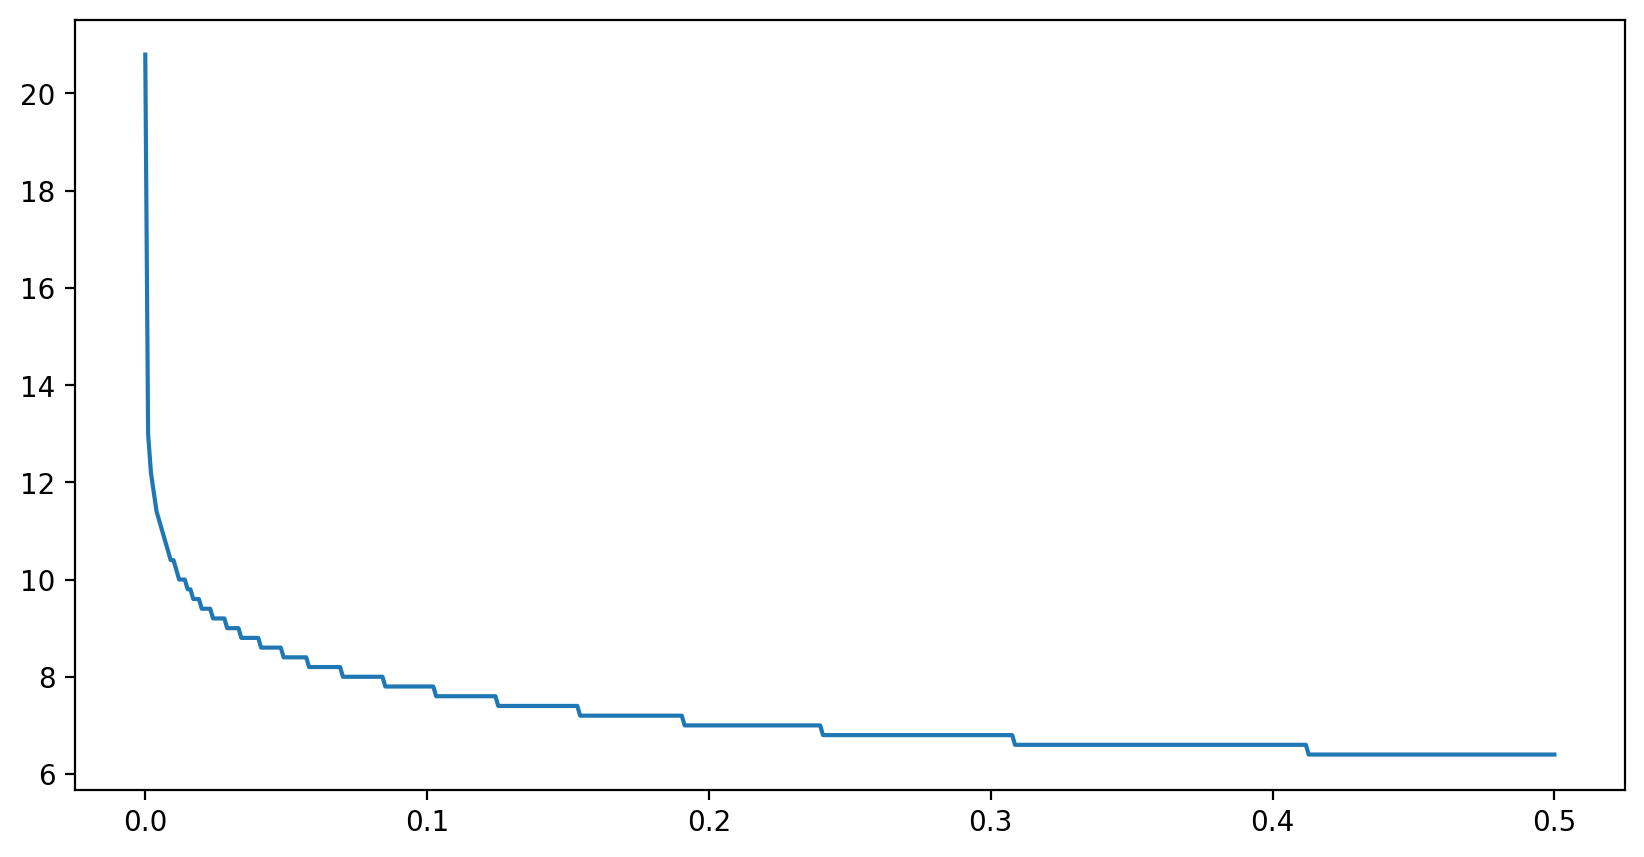

In [98]:
# UTILISEZ CETTE CELLULE POUR LA REPONSE

y0Liste = np.linspace(1e-6, 0.5, 500)

fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(111)
periodeListe = y0Liste * 0

for i in range(y0Liste.size):
    periodeListe[i] = periodeAssociee(y0Liste[i], 1., 1.)

plt.plot(y0Liste, periodeListe)

plt.show()


In [100]:
help(np.polyfit)

Help on _ArrayFunctionDispatcher in module numpy:

polyfit(x, y, deg, rcond=None, full=False, w=None, cov=False)
    Least squares polynomial fit.
    
    .. note::
       This forms part of the old polynomial API. Since version 1.4, the
       new polynomial API defined in `numpy.polynomial` is preferred.
       A summary of the differences can be found in the
       :doc:`transition guide </reference/routines.polynomials>`.
    
    Fit a polynomial ``p(x) = p[0] * x**deg + ... + p[deg]`` of degree `deg`
    to points `(x, y)`. Returns a vector of coefficients `p` that minimises
    the squared error in the order `deg`, `deg-1`, ... `0`.
    
    The `Polynomial.fit <numpy.polynomial.polynomial.Polynomial.fit>` class
    method is recommended for new code as it is more stable numerically. See
    the documentation of the method for more information.
    
    Parameters
    ----------
    x : array_like, shape (M,)
        x-coordinates of the M sample points ``(x[i], y[i])``.
    y 